## Set up

In [24]:
import numpy as np

import tensorflow_datasets as tfds
import tensorflow as tf

tfds.disable_progress_bar()

import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras import losses
from tensorflow.keras import utils

## Set up input pipeline

In [2]:
"""Download data using TFDS"""
dataset, info = tfds.load('imdb_reviews', with_info=True,
                          as_supervised=True)

train_dataset, test_dataset = dataset['train'], dataset['test']

train_dataset.element_spec

"""Initially this returns a dataset of (text, label pairs)"""
for example, label in train_dataset.take(1):
    print('text: ', example.numpy())
    print('label: ', label.numpy())

"""Set value for shuffle data and initialize batch size"""
BUFFER_SIZE = 10000
BATCH_SIZE = 64

train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

for example, label in train_dataset.take(1):
    print('texts: ', example.numpy()[:3])
    print()
    print('labels: ', label.numpy()[:3])

text:  b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it."
label:  0
texts:  [b"Oh, those sneaky Italians. It's not the first time they based a movie on source material without the permission or knowledge of the, in this case, author of the novel. Of course this is not something that is typically Italian but got done quite a lot in the e

## Functions

In [3]:
def plot_graphs(history, metric):
    plt.plot(history.history[metric])
    plt.plot(history.history['val_'+metric], '')
    plt.xlabel('Epochs')
    plt.ylabel(metric)
    plt.legend([metric, 'val_'+metric])
    plt.show()

## Create the text encoder
The raw text loaded by tfds needs to be processed before it can be used in a model. The simplest way to process text for training is using the TextVectorization layer. This layer has many capabilities, but this tutorial sticks to the default behavior.

In [4]:
"""Create the layer, and pass the dataset's text to lthe layer's .adapt() method"""
VOCAB_SIZE = 2500
encoder = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE)
""""The .adapt method sets the layer's vocabulary. ที่เข้าใจคือ เหมือนเอาคำศัพท์มาสร้างเป็น Vocabulary"""
encoder.adapt(train_dataset.map(lambda text, label:text))

In [5]:
""" Here are the first 20 tokens. After the padding and unknown tokens they're sorted by frequency"""
vocab = np.array(encoder.get_vocabulary())
vocab[:20]

array(['', '[UNK]', 'the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i',
       'this', 'that', 'br', 'was', 'as', 'for', 'with', 'movie', 'but'],
      dtype='<U14')

In [6]:
"""แปลง text เป็นตัวเลข (indices)"""
encoded_example = encoder(example)[:3].numpy()
encoded_example

array([[ 452,  144,    1, ...,    0,    0,    0],
       [ 131,   11,   20, ...,    0,    0,    0],
       [ 650,    1, 1458, ...,    0,    0,    0]], dtype=int64)

In [7]:
for n in range(3):
    print("original: ", example[n].numpy())
    print("Round-trip: ", " ".join(vocab[encoded_example[n]]))
    print()

original:  b"Oh, those sneaky Italians. It's not the first time they based a movie on source material without the permission or knowledge of the, in this case, author of the novel. Of course this is not something that is typically Italian but got done quite a lot in the early days of cinema, mostly because they often thought they would be able to get away with it. James M. Cain's publishers managed to keep this movie off American screens until 1976 but nevertheless the movie itself has grown a bit into a well known classic.<br /><br />The movie is not as great to watch as the 1946 American version but it's a great movie nevertheless. This of course not in the least is due to the movie it's great strong story, that is an intriguing one and provides the movie with some great characters and realism. It follows the novel quite closely and is therefore mostly the same as other movie versions of its story, with of course as a difference that it got set in an Italian environment.<br /><br />L

## Create the model

In [8]:
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=512,
        mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [9]:
print([layer.supports_masking for layer in model.layers])

[False, True, True, True, True]


In [10]:
"""Compile model"""
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy'])

In [11]:
"""Train the model"""
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=test_dataset,
                    validation_steps=30)

Epoch 1/10


c:\Users\User\anaconda3\envs\dl_env_1115\lib\site-packages\keras\backend.py:5673: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


391/391 [==============================] - 50s 113ms/step - loss: 0.5532 - accuracy: 0.7080 - val_loss: 0.3820 - val_accuracy: 0.8432
Epoch 2/10
391/391 [==============================] - 41s 105ms/step - loss: 0.3033 - accuracy: 0.8774 - val_loss: 0.3033 - val_accuracy: 0.8719
Epoch 3/10
391/391 [==============================] - 40s 103ms/step - loss: 0.2593 - accuracy: 0.8956 - val_loss: 0.2923 - val_accuracy: 0.8781
Epoch 4/10
391/391 [==============================] - 40s 103ms/step - loss: 0.2387 - accuracy: 0.9069 - val_loss: 0.2963 - val_accuracy: 0.8797
Epoch 5/10
391/391 [==============================] - 40s 103ms/step - loss: 0.2269 - accuracy: 0.9125 - val_loss: 0.3011 - val_accuracy: 0.8828
Epoch 6/10
391/391 [==============================] - 41s 104ms/step - loss: 0.2181 - accuracy: 0.9155 - val_loss: 0.3191 - val_accuracy: 0.8724
Epoch 7/10
391/391 [==============================] - 41s 104ms/step - loss: 0.2073 - accuracy: 0.9212 - val_loss: 0.3101 - val_accuracy: 0.8

In [12]:
test_loss, test_acc = model.evaluate(test_dataset, verbose=1)

print('Test Loss: ', test_loss)
print('Test Accuracy: ', test_acc)

391/391 [==============================] - 18s 46ms/step - loss: 0.3365 - accuracy: 0.8709
Test Loss:  0.3365175127983093
Test Accuracy:  0.8708800077438354


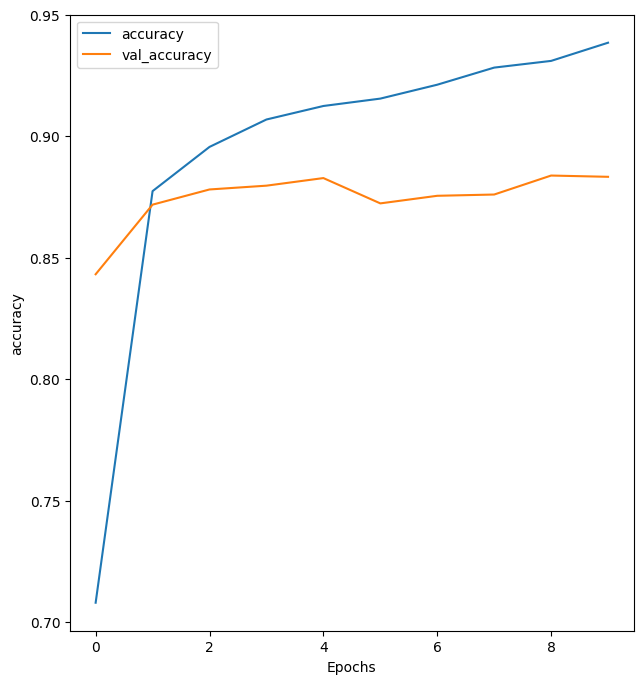

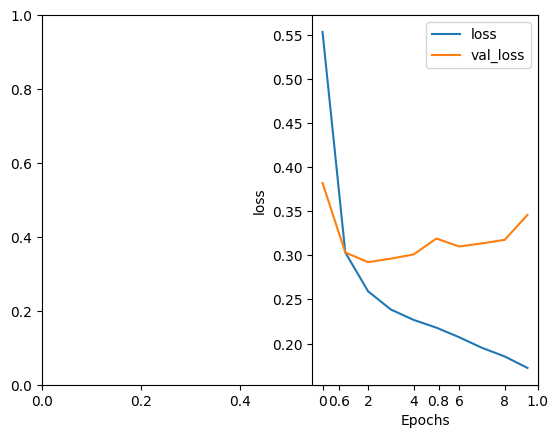

(0.0, 1.0)

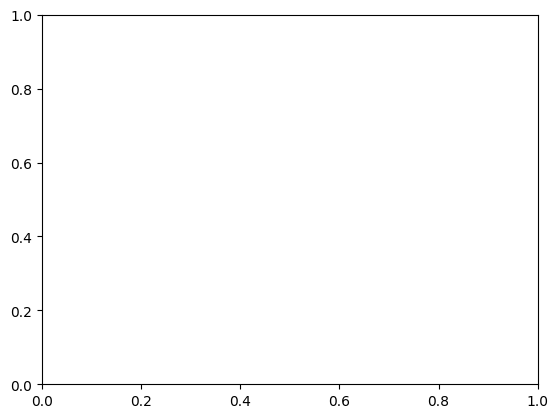

In [13]:
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')
plt.ylim(0, None)

In [22]:
sample_text = ('The movie is good.')
predictions = model.predict(np.array([sample_text]))

1/1 [==============================] - 0s 20ms/step


In [23]:
print(predictions[0])
if predictions[0] < 0.5:
    print("Negative comment.")
else:
    print("Positive comment.")

[0.79254174]
Positive comment.
